In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score, roc_curve
)
from sklearn.compose import ColumnTransformer

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})
PALETTE = ['#2196F3', '#E91E63']

print("All libraries loaded.")

All libraries loaded.


In [6]:
df_raw = pd.read_csv(r'C:\Users\Muhammad imran\Downloads\wallacecommunications.csv')

print("Shape:", df_raw.shape)
print("\nColumn names:", list(df_raw.columns))
print("\nData types:\n", df_raw.dtypes)
print("\nMissing values:\n", df_raw.isnull().sum())
print("\nTarget distribution:\n", df_raw['new_contract_this_campaign'].value_counts())
print("\nClass balance:", df_raw['new_contract_this_campaign'].value_counts(normalize=True).round(3).to_dict())

df_raw.head()

Shape: (50662, 20)

Column names: ['ID', 'town', 'country', 'age', 'job', 'married', 'education', 'arrears', 'current_balance', 'housing', 'has_tv_package', 'last_contact', 'conn_tr', 'last_contact_this_campaign_day', 'last_contact_this_campaign_month', 'this_campaign', 'days_since_last_contact_previous_campaign', 'contacted_during_previous_campaign', 'outcome_previous_campaign', 'new_contract_this_campaign']

Data types:
 ID                                             int64
town                                          object
country                                       object
age                                            int64
job                                           object
married                                       object
education                                     object
arrears                                       object
current_balance                              float64
housing                                       object
has_tv_package                             

,ID,town,country,age,job,married,education,arrears,current_balance,housing,has_tv_package,last_contact,conn_tr,last_contact_this_campaign_day,last_contact_this_campaign_month,this_campaign,days_since_last_contact_previous_campaign,contacted_during_previous_campaign,outcome_previous_campaign,new_contract_this_campaign
0,32390233,Bristol,UK,39,management,married,tertiary,no,-1.90,no,yes,unknown,4,11,jun,8,-1,0,unknown,yes
1,41226029,Basildon,UK,53,housemaid,married,primary,no,3.62,no,no,cellular,1,28,jul,2,-1,0,unknown,yes
2,85498057,Blackburn,UK,79,retired,divorced,primary,no,27.87,no,no,telephone,3,13,jul,1,377,1,success,yes
3,76539627,Oldham,UK,43,services,single,secondary,no,5.50,yes,no,cellular,3,13,may,2,-1,0,unknown,no
4,76290986,Middlesbrough,UK,35,technician,single,secondary,no,3.44,no,no,cellular,2,27,aug,16,-1,0,unknown,yes


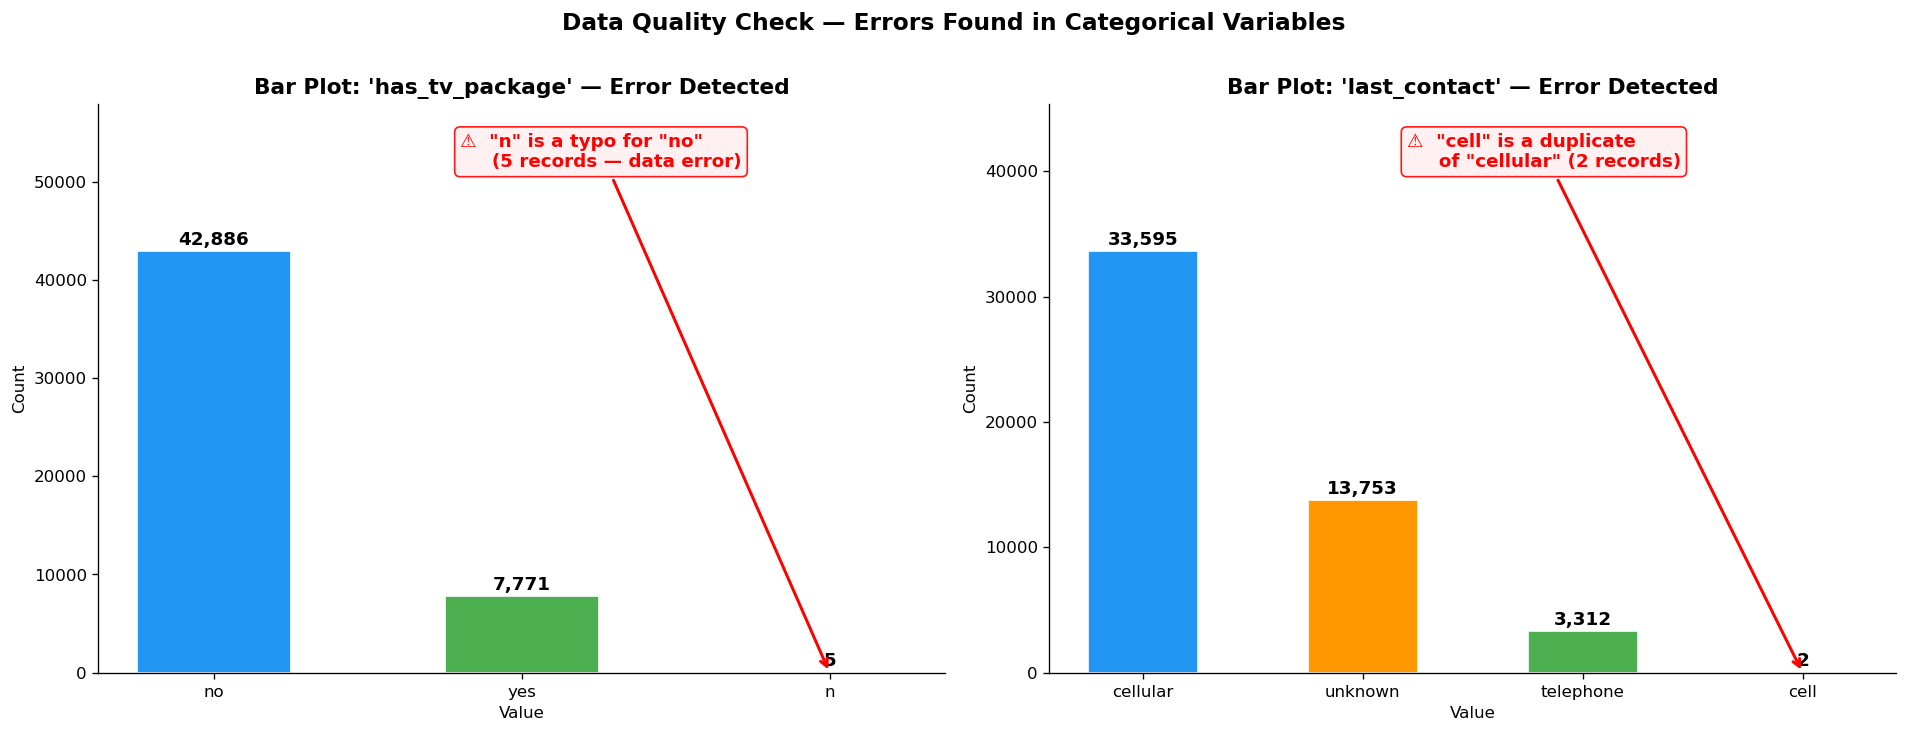

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: has_tv_package
tv_counts = df_raw['has_tv_package'].value_counts()
bars1 = axes[0].bar(tv_counts.index, tv_counts.values,
                    color=['#2196F3', '#4CAF50', '#E91E63'], edgecolor='white', width=0.5)
axes[0].set_title("Bar Plot: 'has_tv_package' — Error Detected", fontweight='bold', fontsize=13)
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Count')
axes[0].set_ylim(0, tv_counts.max() * 1.35)  # extra headroom above bars

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 300,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Annotation in top-right corner — no overlap with bars
axes[0].annotate(
    '⚠  "n" is a typo for "no"\n     (5 records — data error)',
    xy=(2, tv_counts['n']),              # arrow tip: top of the 'n' bar
    xytext=(0.8, tv_counts.max() * 1.2), # text: top-right area
    arrowprops=dict(arrowstyle='->', color='red', lw=1.8),
    color='red', fontsize=11, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f0', ec='red', alpha=0.9)
)

# Plot 2: last_contact
lc_counts = df_raw['last_contact'].value_counts()
bars2 = axes[1].bar(lc_counts.index, lc_counts.values,
                    color=['#2196F3', '#FF9800', '#4CAF50', '#E91E63'], edgecolor='white', width=0.5)
axes[1].set_title("Bar Plot: 'last_contact' — Error Detected", fontweight='bold', fontsize=13)
axes[1].set_xlabel('Value'); axes[1].set_ylabel('Count')
axes[1].set_ylim(0, lc_counts.max() * 1.35)  # extra headroom above bars

for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Annotation in top-right corner — no overlap with bars
axes[1].annotate(
    '⚠  "cell" is a duplicate\n     of "cellular" (2 records)',
    xy=(3, lc_counts['cell']),            # arrow tip: top of 'cell' bar
    xytext=(1.2, lc_counts.max() * 1.2),  # text: top-right area
    arrowprops=dict(arrowstyle='->', color='red', lw=1.8),
    color='red', fontsize=11, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f0', ec='red', alpha=0.9)
)

plt.suptitle("Data Quality Check — Errors Found in Categorical Variables",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('error_detection_barplots.png', bbox_inches='tight', dpi=150)
plt.show()

In [8]:
df = df_raw.copy()

# Fix 1: typo 'n' → 'no' in has_tv_package
df['has_tv_package'] = df['has_tv_package'].replace('n', 'no')

# Fix 2: abbreviation 'cell' → 'cellular' in last_contact
df['last_contact'] = df['last_contact'].replace('cell', 'cellular')

print("has_tv_package after fix:", df['has_tv_package'].unique())
print("last_contact after fix:  ", df['last_contact'].unique())
print("\nData cleaning complete. All", len(df), "records retained.")

has_tv_package after fix: ['yes' 'no']
last_contact after fix:   ['unknown' 'cellular' 'telephone']

Data cleaning complete. All 50662 records retained.


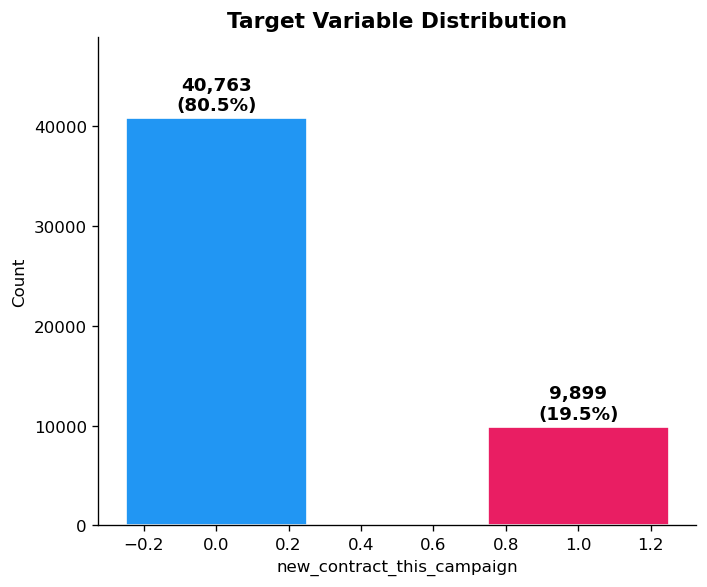

Class imbalance: ~80.4% no, ~19.6% yes — accuracy alone is misleading as a metric.


In [28]:
fig, ax = plt.subplots(figsize=(6, 5))
target_counts = df['new_contract_this_campaign'].value_counts()
bars = ax.bar(target_counts.index, target_counts.values,
              color=PALETTE, edgecolor='white', width=0.5)

ax.set_title('Target Variable Distribution', fontweight='bold', fontsize=13)
ax.set_xlabel('new_contract_this_campaign')
ax.set_ylabel('Count')
ax.set_ylim(0, target_counts.max() * 1.2)  # <-- extra headroom so labels don't hit the title

for bar in bars:
    pct = bar.get_height() / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 400,          # <-- small gap above bar top
            f'{int(bar.get_height()):,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Class imbalance: ~80.4% no, ~19.6% yes — accuracy alone is misleading as a metric.")

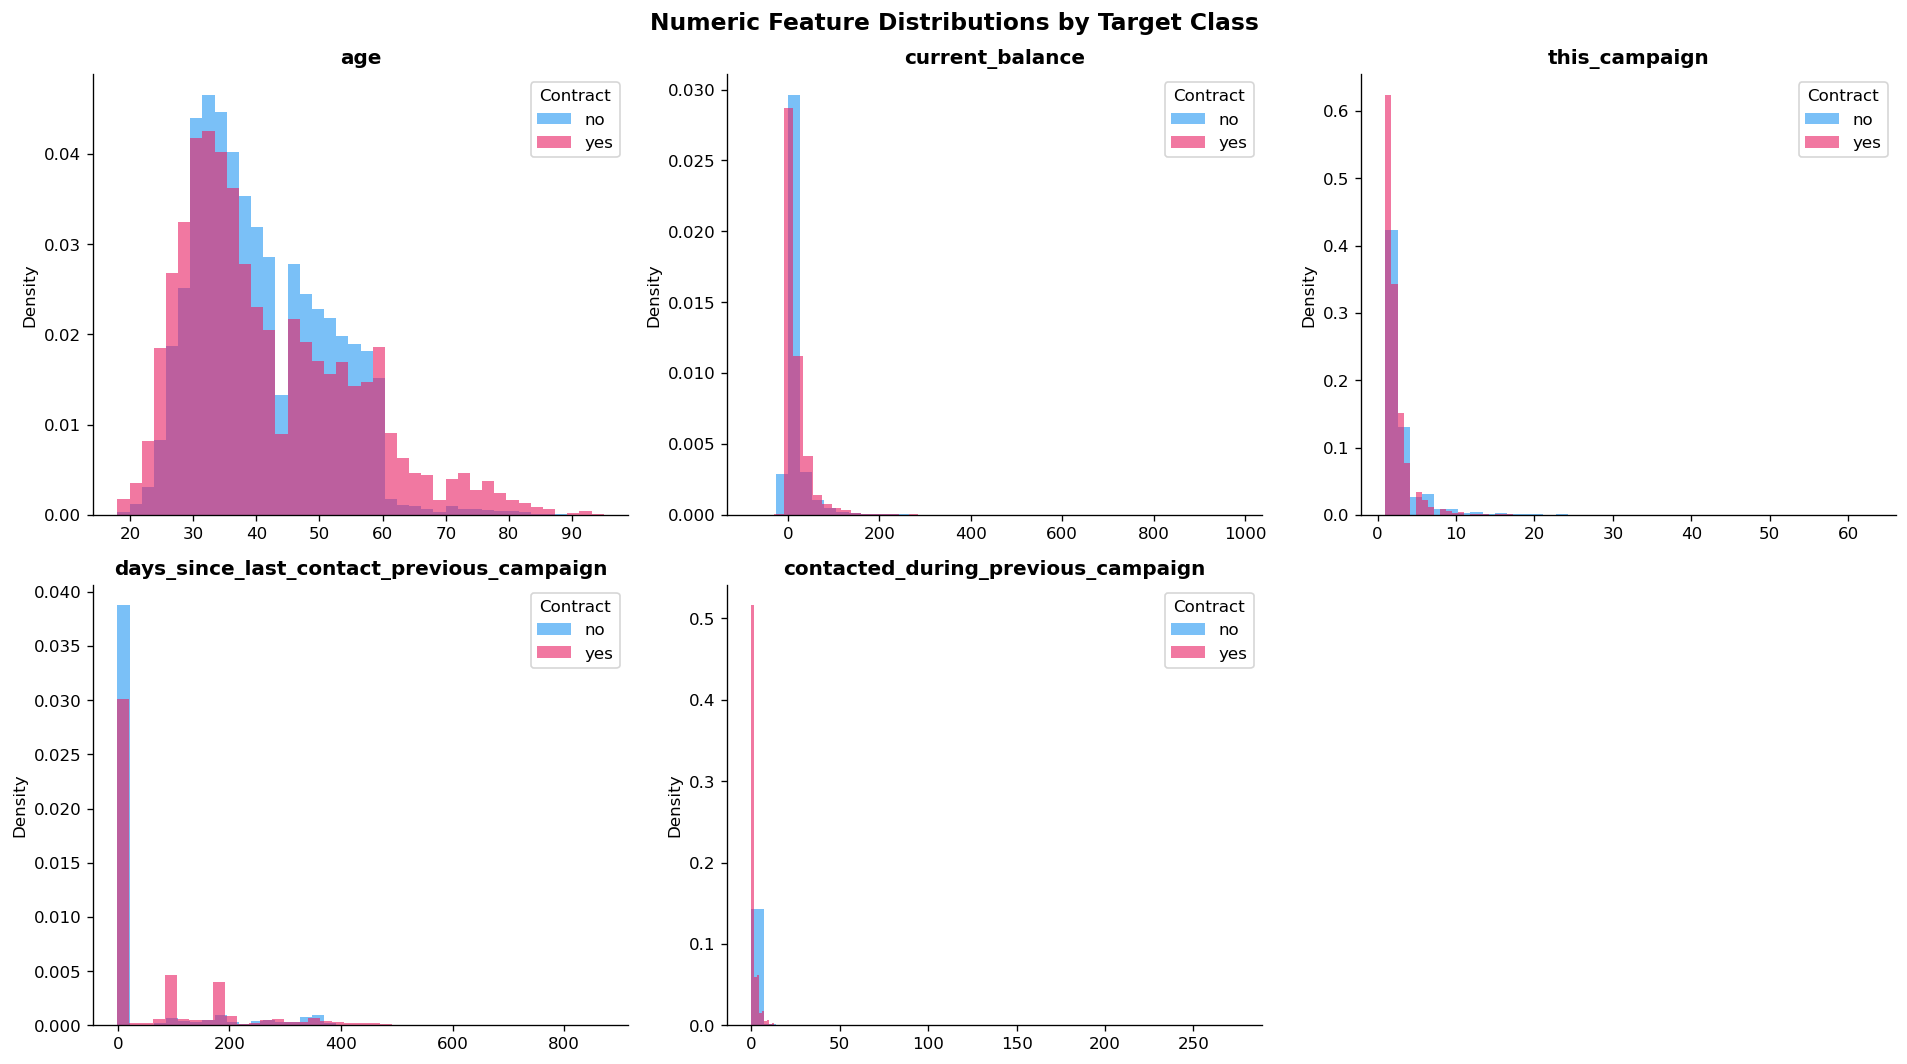

In [12]:
# Numeric feature distributions by class
numeric_cols = ['age', 'current_balance', 'this_campaign',
                'days_since_last_contact_previous_campaign',
                'contacted_during_previous_campaign']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, color in zip(['no', 'yes'], PALETTE):
        axes[i].hist(df[df['new_contract_this_campaign'] == label][col],
                     bins=40, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend(title='Contract')

axes[-1].axis('off')
fig.suptitle('Numeric Feature Distributions by Target Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numeric_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

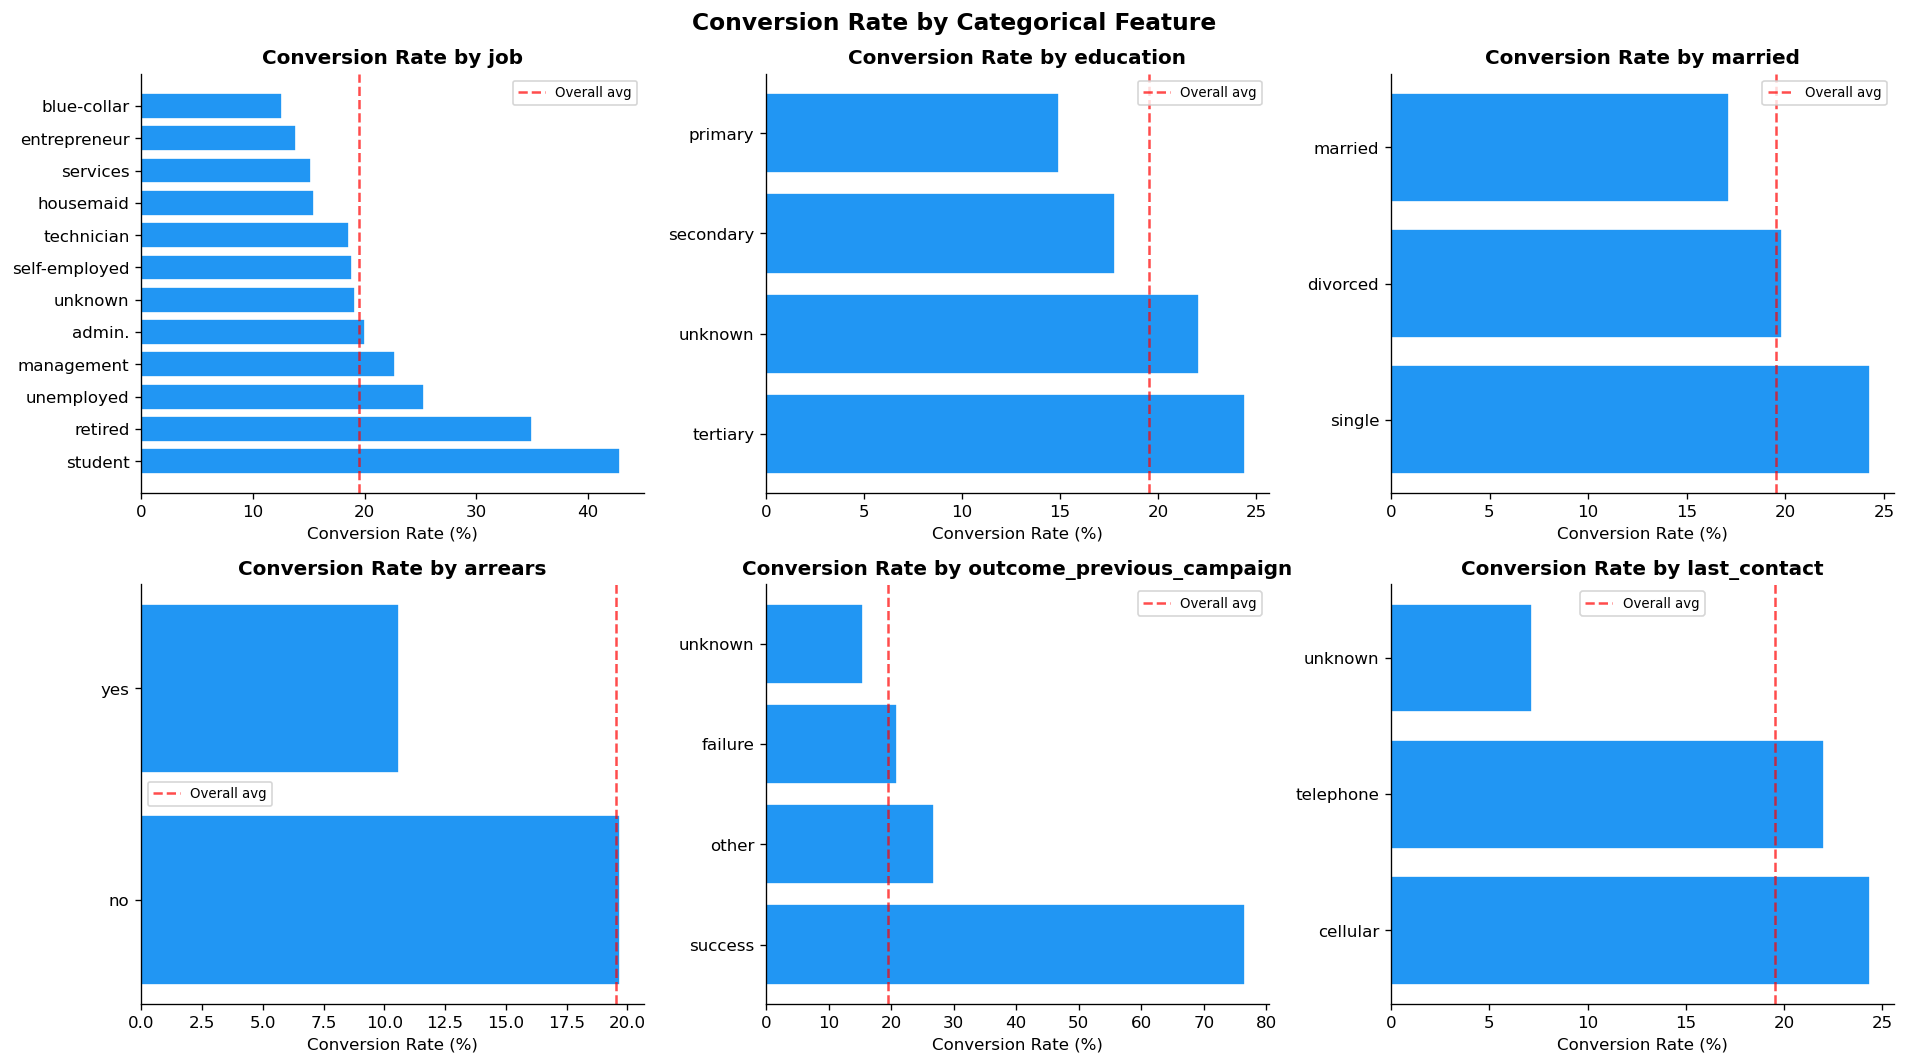

In [13]:
# Categorical conversion rates
cat_cols = ['job', 'education', 'married', 'arrears',
            'outcome_previous_campaign', 'last_contact']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
overall_rate = df['new_contract_this_campaign'].eq('yes').mean() * 100

for i, col in enumerate(cat_cols):
    rates = df.groupby(col)['new_contract_this_campaign'].apply(
        lambda x: (x == 'yes').mean() * 100
    ).sort_values(ascending=False)
    axes[i].barh(rates.index, rates.values, color='#2196F3', edgecolor='white')
    axes[i].set_title(f'Conversion Rate by {col}', fontweight='bold')
    axes[i].set_xlabel('Conversion Rate (%)')
    axes[i].axvline(x=overall_rate, linestyle='--', color='red', alpha=0.7, label='Overall avg')
    axes[i].legend(fontsize=8)

fig.suptitle('Conversion Rate by Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_conversion_rates.png', bbox_inches='tight', dpi=150)
plt.show()

In [14]:
# Drop non-informative columns
# ID: unique identifier — no predictive signal
# town, country: too high-cardinality, not generalisable to new customers
# last_contact_this_campaign_day: day-of-month unlikely to carry meaningful signal
COLS_TO_DROP = ['ID', 'town', 'country', 'last_contact_this_campaign_day']
df = df.drop(columns=COLS_TO_DROP)

# Feature type decisions
NUMERIC_FEATURES = [
    'age',                                        # continuous
    'current_balance',                            # continuous (can be negative)
    'this_campaign',                              # discrete count
    'days_since_last_contact_previous_campaign',  # discrete (-1 = never contacted)
    'contacted_during_previous_campaign',         # discrete count
    'conn_tr',                                    # discrete grouping ID — treated as numeric
]

CATEGORICAL_FEATURES = [
    'job',
    'married',
    'education',
    'arrears',
    'housing',
    'has_tv_package',
    'last_contact',
    'last_contact_this_campaign_month',
    'outcome_previous_campaign',
]

TARGET = 'new_contract_this_campaign'

print("NUMERIC features:    ", NUMERIC_FEATURES)
print("\nCATEGORICAL features:", CATEGORICAL_FEATURES)

print("""
Variable type decisions and consequence:
  - Numeric features are scaled with StandardScaler (mean=0, std=1).
    This is essential for Logistic Regression and the Neural Network, which
    are sensitive to feature scale differences.
  - Categorical features are encoded with OneHotEncoder (drop='first' to
    avoid the dummy variable trap / multicollinearity).
  - 'conn_tr' is treated as NUMERIC (ordinal grouping ID). If instead treated
    as categorical, OHE would allow the model to learn a separate effect per
    group with no assumed ordering — potentially more flexible. Treating it
    as numeric imposes an ordinal relationship that may not hold, potentially
    causing the model to miss important non-linear group-level effects.
""")

# Encode target: yes=1, no=0
df[TARGET] = (df[TARGET] == 'yes').astype(int)
print("Target encoded: yes=1, no=0")
print("Final dataset shape:", df.shape)

NUMERIC features:     ['age', 'current_balance', 'this_campaign', 'days_since_last_contact_previous_campaign', 'contacted_during_previous_campaign', 'conn_tr']

CATEGORICAL features: ['job', 'married', 'education', 'arrears', 'housing', 'has_tv_package', 'last_contact', 'last_contact_this_campaign_month', 'outcome_previous_campaign']

Variable type decisions and consequence:
  - Numeric features are scaled with StandardScaler (mean=0, std=1).
    This is essential for Logistic Regression and the Neural Network, which
    are sensitive to feature scale differences.
  - Categorical features are encoded with OneHotEncoder (drop='first' to
    avoid the dummy variable trap / multicollinearity).
  - 'conn_tr' is treated as NUMERIC (ordinal grouping ID). If instead treated
    as categorical, OHE would allow the model to learn a separate effect per
    group with no assumed ordering — potentially more flexible. Treating it
    as numeric imposes an ordinal relationship that may not hold, pot

In [15]:
# Split strategy: 60% train | 20% validate | 20% test
# All splits are STRATIFIED to preserve the ~80/20 class ratio.
# The validate set is used exclusively for hyperparameter selection.
# The test set is held out completely until the very end to give an
# unbiased estimate of generalisation performance.

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

# Step 1: hold out 20% as test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Step 2: split remaining 80% into 60% train + 20% validate
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval
)

print(f"Train set:    {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validate set: {X_val.shape[0]:,} rows  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:     {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nClass balance preserved in each split:")
for name, ys in [('Train', y_train), ('Validate', y_val), ('Test', y_test)]:
    print(f"  {name}: {ys.mean()*100:.2f}% positive (contract=yes)")

Train set:    30,396 rows  (60.0%)
Validate set: 10,133 rows  (20.0%)
Test set:     10,133 rows  (20.0%)

Class balance preserved in each split:
  Train: 19.54% positive (contract=yes)
  Validate: 19.54% positive (contract=yes)
  Test: 19.54% positive (contract=yes)


In [16]:
# Numeric  → StandardScaler  (zero mean, unit variance)
# Categorical → OneHotEncoder (drop first level to avoid multicollinearity)
# Fitted ONLY on training data to prevent data leakage into val/test

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore',
                              sparse_output=False), CATEGORICAL_FEATURES)
    ],
    remainder='drop'
)

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

print(f"Processed feature dimensions: {X_train_proc.shape[1]} features")
print("Preprocessing pipeline fitted on training data only — no data leakage.")

Processed feature dimensions: 42 features
Preprocessing pipeline fitted on training data only — no data leakage.


In [17]:
def evaluate_model(model, X_proc, y_true, tag=''):
    y_pred = model.predict(X_proc)
    y_prob = model.predict_proba(X_proc)[:, 1]
    auc   = roc_auc_score(y_true, y_prob)
    f1    = f1_score(y_true, y_pred, average='macro')
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec   = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    print(f"[{tag}]  ROC-AUC={auc:.4f}  F1-macro={f1:.4f}  "
          f"Acc={acc:.4f}  Prec(yes)={prec:.4f}  Rec(yes)={rec:.4f}")
    return dict(roc_auc=auc, f1_macro=f1, accuracy=acc,
                precision=prec, recall=rec)

print("Helper function ready.")
print("""
Metric justification:
  Given class imbalance (~80% no, ~20% yes), ACCURACY is misleading —
  a trivial model that always predicts 'no' scores ~80%.
  ROC-AUC is the PRIMARY tuning metric: it measures discriminatory power
  across ALL decision thresholds, making it robust to class imbalance.
  F1-MACRO averages F1 across both classes equally — it penalises the
  model for ignoring the minority class (yes/contract).
""")

Helper function ready.

Metric justification:
  Given class imbalance (~80% no, ~20% yes), ACCURACY is misleading —
  a trivial model that always predicts 'no' scores ~80%.
  ROC-AUC is the PRIMARY tuning metric: it measures discriminatory power
  across ALL decision thresholds, making it robust to class imbalance.
  F1-MACRO averages F1 across both classes equally — it penalises the
  model for ignoring the minority class (yes/contract).



In [18]:
# Hyperparameter: C (inverse regularisation strength)
# Larger C = weaker L2 penalty = closer to unregularised.
# Values searched on a log scale from 0.001 to 10.
# class_weight='balanced' upweights the minority class automatically.

lr_results = []
print("=== Logistic Regression Grid Search ===\n")

for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    lr = LogisticRegression(C=C, class_weight='balanced', solver='lbfgs',
                            max_iter=1000, random_state=SEED)
    lr.fit(X_train_proc, y_train)
    metrics = evaluate_model(lr, X_val_proc, y_val, f'LR C={C}')
    lr_results.append({'Model': f'Logistic Regression  C={C}',
                       'Hyperparams': f'C={C}', **metrics})

lr_df = pd.DataFrame(lr_results)
best_lr_idx = lr_df['roc_auc'].idxmax()
best_C = float(lr_df.loc[best_lr_idx, 'Hyperparams'].split('=')[1])

print(f"\n>>> Best LR: C={best_C}  →  Val ROC-AUC={lr_df.loc[best_lr_idx,'roc_auc']:.4f}")

# Re-train best LR
lr_best = LogisticRegression(C=best_C, class_weight='balanced', solver='lbfgs',
                              max_iter=1000, random_state=SEED)
lr_best.fit(X_train_proc, y_train)

=== Logistic Regression Grid Search ===

[LR C=0.001]  ROC-AUC=0.7466  F1-macro=0.6207  Acc=0.6888  Prec(yes)=0.3480  Rec(yes)=0.6783
[LR C=0.01]  ROC-AUC=0.7637  F1-macro=0.6560  Acc=0.7359  Prec(yes)=0.3935  Rec(yes)=0.6495
[LR C=0.1]  ROC-AUC=0.7644  F1-macro=0.6651  Acc=0.7511  Prec(yes)=0.4102  Rec(yes)=0.6253
[LR C=1.0]  ROC-AUC=0.7642  F1-macro=0.6633  Acc=0.7506  Prec(yes)=0.4086  Rec(yes)=0.6177
[LR C=10.0]  ROC-AUC=0.7641  F1-macro=0.6630  Acc=0.7505  Prec(yes)=0.4084  Rec(yes)=0.6167

>>> Best LR: C=0.1  →  Val ROC-AUC=0.7644


LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42)

In [19]:
# Hyperparameters:
#   max_depth      — controls tree depth; limits overfitting
#   min_samples_leaf — minimum samples per leaf; smooths predictions
# Strategy: grid search; best combo chosen by validation ROC-AUC

dt_results = []
print("=== Decision Tree Grid Search ===\n")

for max_depth in [3, 5, 7, 10]:
    for min_leaf in [20, 50, 100]:
        dt = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_leaf,
                                    class_weight='balanced', random_state=SEED)
        dt.fit(X_train_proc, y_train)
        metrics = evaluate_model(dt, X_val_proc, y_val,
                                 f'DT depth={max_depth} leaf={min_leaf}')
        dt_results.append({'Model': f'Decision Tree  depth={max_depth}  leaf={min_leaf}',
                           'max_depth': max_depth, 'min_leaf': min_leaf, **metrics})

dt_df = pd.DataFrame(dt_results)
best_dt_row = dt_df.loc[dt_df['roc_auc'].idxmax()]
best_depth = int(best_dt_row['max_depth'])
best_leaf  = int(best_dt_row['min_leaf'])

print(f"\n>>> Best DT: depth={best_depth}  leaf={best_leaf}  →  Val ROC-AUC={best_dt_row['roc_auc']:.4f}")

# Re-train best DT
dt_best = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=best_leaf,
                                  class_weight='balanced', random_state=SEED)
dt_best.fit(X_train_proc, y_train)

=== Decision Tree Grid Search ===

[DT depth=3 leaf=20]  ROC-AUC=0.7040  F1-macro=0.5986  Acc=0.6677  Prec(yes)=0.3243  Rec(yes)=0.6465
[DT depth=3 leaf=50]  ROC-AUC=0.7040  F1-macro=0.5986  Acc=0.6677  Prec(yes)=0.3243  Rec(yes)=0.6465
[DT depth=3 leaf=100]  ROC-AUC=0.7040  F1-macro=0.5986  Acc=0.6677  Prec(yes)=0.3243  Rec(yes)=0.6465
[DT depth=5 leaf=20]  ROC-AUC=0.7320  F1-macro=0.6642  Acc=0.7654  Prec(yes)=0.4233  Rec(yes)=0.5535
[DT depth=5 leaf=50]  ROC-AUC=0.7320  F1-macro=0.6642  Acc=0.7654  Prec(yes)=0.4233  Rec(yes)=0.5535
[DT depth=5 leaf=100]  ROC-AUC=0.7312  F1-macro=0.6620  Acc=0.7624  Prec(yes)=0.4187  Rec(yes)=0.5566
[DT depth=7 leaf=20]  ROC-AUC=0.7502  F1-macro=0.6746  Acc=0.7712  Prec(yes)=0.4357  Rec(yes)=0.5788
[DT depth=7 leaf=50]  ROC-AUC=0.7489  F1-macro=0.6752  Acc=0.7715  Prec(yes)=0.4364  Rec(yes)=0.5808
[DT depth=7 leaf=100]  ROC-AUC=0.7493  F1-macro=0.6396  Acc=0.7159  Prec(yes)=0.3712  Rec(yes)=0.6545
[DT depth=10 leaf=20]  ROC-AUC=0.7736  F1-macro=0.663

DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=20, random_state=42)

In [20]:
# Hyperparameters:
#   hidden_layer_sizes — number and size of hidden layers (architecture)
#   alpha              — L2 regularisation penalty on weights
# activation='relu', solver='adam' are standard best-practice defaults.
# early_stopping=True halts training when validation loss stops improving,
# preventing overfitting without manually tuning epoch count.

nn_configs = [
    {'hidden_layer_sizes': (64,),         'alpha': 0.001},
    {'hidden_layer_sizes': (64,),         'alpha': 0.01},
    {'hidden_layer_sizes': (128, 64),     'alpha': 0.001},
    {'hidden_layer_sizes': (128, 64),     'alpha': 0.01},
    {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.001},
    {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.01},
]

nn_results = []
print("=== Neural Network (MLP) Grid Search ===\n")

for cfg in nn_configs:
    nn = MLPClassifier(
        hidden_layer_sizes=cfg['hidden_layer_sizes'],
        alpha=cfg['alpha'],
        activation='relu',
        solver='adam',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=SEED
    )
    nn.fit(X_train_proc, y_train)
    label = f"MLP {cfg['hidden_layer_sizes']}  α={cfg['alpha']}"
    metrics = evaluate_model(nn, X_val_proc, y_val, label)
    nn_results.append({'Model': label,
                       'layers': str(cfg['hidden_layer_sizes']),
                       'alpha': cfg['alpha'], **metrics})

nn_df = pd.DataFrame(nn_results)
best_nn_row = nn_df.loc[nn_df['roc_auc'].idxmax()]
best_layers = ast.literal_eval(best_nn_row['layers'])
best_alpha  = float(best_nn_row['alpha'])

print(f"\n>>> Best NN: layers={best_layers}  α={best_alpha}  →  Val ROC-AUC={best_nn_row['roc_auc']:.4f}")

# Re-train best NN
nn_best = MLPClassifier(
    hidden_layer_sizes=best_layers,
    alpha=best_alpha,
    activation='relu',
    solver='adam',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=SEED
)
nn_best.fit(X_train_proc, y_train)

=== Neural Network (MLP) Grid Search ===

[MLP (64,)  α=0.001]  ROC-AUC=0.7808  F1-macro=0.6666  Acc=0.8382  Prec(yes)=0.6923  Rec(yes)=0.3091
[MLP (64,)  α=0.01]  ROC-AUC=0.7824  F1-macro=0.6859  Acc=0.8411  Prec(yes)=0.6796  Rec(yes)=0.3535
[MLP (128, 64)  α=0.001]  ROC-AUC=0.7846  F1-macro=0.6709  Acc=0.8395  Prec(yes)=0.6967  Rec(yes)=0.3167
[MLP (128, 64)  α=0.01]  ROC-AUC=0.7861  F1-macro=0.6641  Acc=0.8383  Prec(yes)=0.6989  Rec(yes)=0.3025
[MLP (128, 64, 32)  α=0.001]  ROC-AUC=0.7827  F1-macro=0.6570  Acc=0.8379  Prec(yes)=0.7119  Rec(yes)=0.2859
[MLP (128, 64, 32)  α=0.01]  ROC-AUC=0.7864  F1-macro=0.6947  Acc=0.8371  Prec(yes)=0.6334  Rec(yes)=0.3944

>>> Best NN: layers=(128, 64, 32)  α=0.01  →  Val ROC-AUC=0.7864


MLPClassifier(alpha=0.01, early_stopping=True, hidden_layer_sizes=(128, 64, 32),
              max_iter=300, random_state=42)

In [21]:
all_models_df = pd.concat([
    lr_df[['Model', 'roc_auc', 'f1_macro', 'accuracy']],
    dt_df[['Model', 'roc_auc', 'f1_macro', 'accuracy']],
    nn_df[['Model', 'roc_auc', 'f1_macro', 'accuracy']]
]).reset_index(drop=True)

all_models_df.columns = ['Model', 'ROC-AUC (Val)', 'F1-Macro (Val)', 'Accuracy (Val)']
all_models_df = all_models_df.sort_values('ROC-AUC (Val)', ascending=False).reset_index(drop=True)

print("=== ALL MODELS — VALIDATION SET PERFORMANCE (sorted by ROC-AUC) ===\n")
print(all_models_df.round(4).to_string(index=False))

print("""
How hyperparameter values were chosen:
  All hyperparameters were selected using a manual grid search evaluated
  on the VALIDATION set using ROC-AUC as the selection criterion.
  The validation set was not used in training — this ensures the
  hyperparameter selection does not overfit to the test set.
""")

=== ALL MODELS — VALIDATION SET PERFORMANCE (sorted by ROC-AUC) ===

                            Model  ROC-AUC (Val)  F1-Macro (Val)  Accuracy (Val)
        MLP (128, 64, 32)  α=0.01         0.7864          0.6947          0.8371
            MLP (128, 64)  α=0.01         0.7861          0.6641          0.8383
           MLP (128, 64)  α=0.001         0.7846          0.6709          0.8395
       MLP (128, 64, 32)  α=0.001         0.7827          0.6570          0.8379
                MLP (64,)  α=0.01         0.7824          0.6859          0.8411
               MLP (64,)  α=0.001         0.7808          0.6666          0.8382
 Decision Tree  depth=10  leaf=20         0.7736          0.6637          0.7437
 Decision Tree  depth=10  leaf=50         0.7678          0.6559          0.7342
       Logistic Regression  C=0.1         0.7644          0.6651          0.7511
       Logistic Regression  C=1.0         0.7642          0.6633          0.7506
      Logistic Regression  C=10.0       

In [22]:
# Compare the single best model from each family on validation
print("=== BEST MODEL FROM EACH FAMILY — VALIDATION SET ===\n")
lr_val = evaluate_model(lr_best, X_val_proc, y_val, 'Logistic Regression')
dt_val = evaluate_model(dt_best, X_val_proc, y_val, 'Decision Tree')
nn_val = evaluate_model(nn_best, X_val_proc, y_val, 'Neural Network')

summary = pd.DataFrame({
    'Model':          ['Logistic Regression', 'Decision Tree', 'Neural Network'],
    'ROC-AUC':        [lr_val['roc_auc'], dt_val['roc_auc'], nn_val['roc_auc']],
    'F1-Macro':       [lr_val['f1_macro'], dt_val['f1_macro'], nn_val['f1_macro']],
    'Precision(yes)': [lr_val['precision'], dt_val['precision'], nn_val['precision']],
    'Recall(yes)':    [lr_val['recall'], dt_val['recall'], nn_val['recall']],
})

print("\n", summary.round(4).to_string(index=False))

# Auto-select best by ROC-AUC
best_name = summary.loc[summary['ROC-AUC'].idxmax(), 'Model']
model_map  = {'Logistic Regression': lr_best,
               'Decision Tree':       dt_best,
               'Neural Network':      nn_best}
final_model = model_map[best_name]

print(f"\n>>> FINAL MODEL SELECTED: {best_name}")
print("""
Justification:
  The model with the highest ROC-AUC on the validation set was selected.
  ROC-AUC is the most appropriate metric here because:
    (1) The classes are imbalanced (~80/20), so accuracy is misleading.
    (2) Wallace Communications needs to RANK customers by likelihood to convert —
        ROC-AUC directly measures this ranking ability across all thresholds.
    (3) F1-Macro confirms the ranking, ensuring the minority class (yes) is
        not being ignored by the winning model.
""")

# ── NOW evaluate on test set for the FIRST time ─────────────────────────────
print(f"=== {best_name} — HELD-OUT TEST SET (first and only look) ===\n")
test_metrics = evaluate_model(final_model, X_test_proc, y_test, f'{best_name} [TEST]')

=== BEST MODEL FROM EACH FAMILY — VALIDATION SET ===

[Logistic Regression]  ROC-AUC=0.7644  F1-macro=0.6651  Acc=0.7511  Prec(yes)=0.4102  Rec(yes)=0.6253
[Decision Tree]  ROC-AUC=0.7736  F1-macro=0.6637  Acc=0.7437  Prec(yes)=0.4039  Rec(yes)=0.6551
[Neural Network]  ROC-AUC=0.7864  F1-macro=0.6947  Acc=0.8371  Prec(yes)=0.6334  Rec(yes)=0.3944

               Model  ROC-AUC  F1-Macro  Precision(yes)  Recall(yes)
Logistic Regression   0.7644    0.6651          0.4102       0.6253
      Decision Tree   0.7736    0.6637          0.4039       0.6551
     Neural Network   0.7864    0.6947          0.6334       0.3944

>>> FINAL MODEL SELECTED: Neural Network

Justification:
  The model with the highest ROC-AUC on the validation set was selected.
  ROC-AUC is the most appropriate metric here because:
    (1) The classes are imbalanced (~80/20), so accuracy is misleading.
    (2) Wallace Communications needs to RANK customers by likelihood to convert —
        ROC-AUC directly measures thi

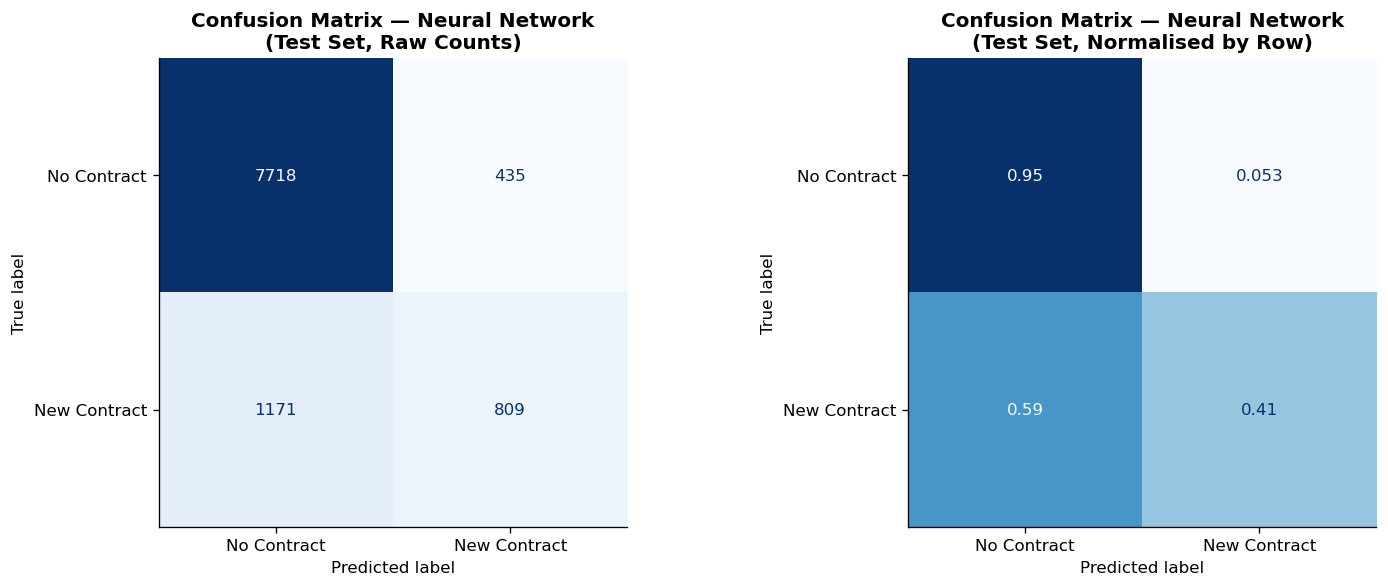

TN=7,718  FP=435  FN=1,171  TP=809

Confusion matrix interpretation:
  TP=809  — customers correctly predicted to sign up (CALLS THAT CONVERT)
  FP=435  — customers incorrectly targeted  (WASTED CALL-CENTRE COST)
  FN=1,171  — actual converters the model missed (LOST REVENUE OPPORTUNITY)
  TN=7,718 — correctly identified non-converters (CALLS SAVED)

  Of all actual converters, the model captures 40.9% (recall).
  Of all predicted converters, 65.0% actually convert (precision).
  This compares to a 19.5% baseline hit-rate with no model.
  The model significantly improves call-centre targeting efficiency.


Full Classification Report:

              precision    recall  f1-score   support

          No       0.87      0.95      0.91      8153
         Yes       0.65      0.41      0.50      1980

    accuracy                           0.84     10133
   macro avg       0.76      0.68      0.70     10133
weighted avg       0.83      0.84      0.83     10133



In [23]:
y_pred_test = final_model.predict(X_test_proc)
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['No Contract', 'New Contract']
                       ).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_name}\n(Test Set, Raw Counts)',
                  fontweight='bold')

# Normalised (row-wise)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(3),
                       display_labels=['No Contract', 'New Contract']
                       ).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix — {best_name}\n(Test Set, Normalised by Row)',
                  fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix_final.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"""
Confusion matrix interpretation:
  TP={tp:,}  — customers correctly predicted to sign up (CALLS THAT CONVERT)
  FP={fp:,}  — customers incorrectly targeted  (WASTED CALL-CENTRE COST)
  FN={fn:,}  — actual converters the model missed (LOST REVENUE OPPORTUNITY)
  TN={tn:,} — correctly identified non-converters (CALLS SAVED)

  Of all actual converters, the model captures {tp/(tp+fn)*100:.1f}% (recall).
  Of all predicted converters, {tp/(tp+fp)*100:.1f}% actually convert (precision).
  This compares to a {y_test.mean()*100:.1f}% baseline hit-rate with no model.
  The model significantly improves call-centre targeting efficiency.
""")

print("\nFull Classification Report:\n")
print(classification_report(y_test, y_pred_test, target_names=['No', 'Yes']))

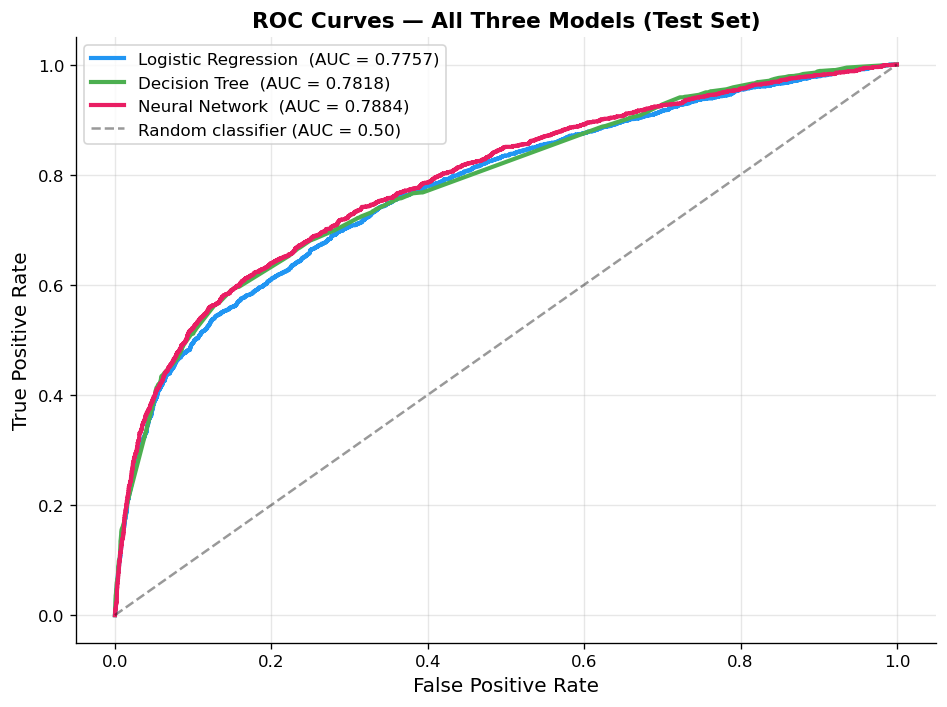

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = {'Logistic Regression': '#2196F3',
          'Decision Tree':       '#4CAF50',
          'Neural Network':      '#E91E63'}

for name, model in model_map.items():
    y_prob = model.predict_proba(X_test_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})',
            color=colors[name], linewidth=2.5)

ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random classifier (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Three Models (Test Set)',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

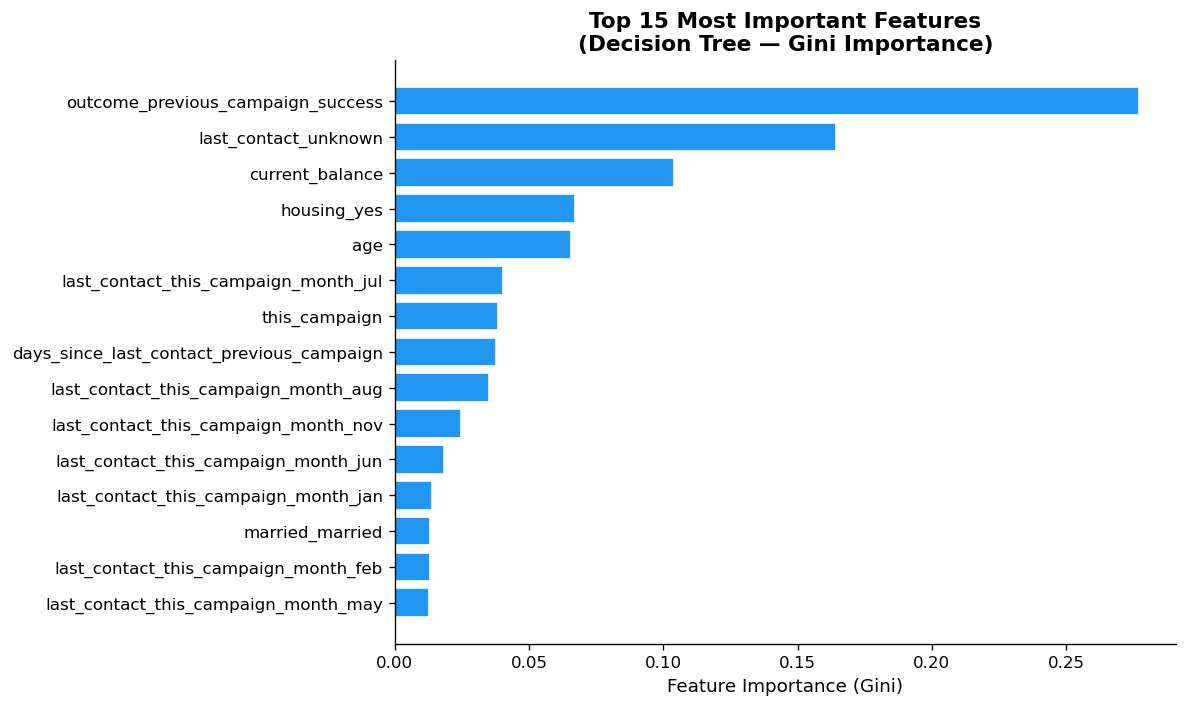

In [25]:
# ── Feature importances from Decision Tree ───────────────────────────────────
feature_names_num = NUMERIC_FEATURES
feature_names_cat = list(
    preprocessor.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES)
)
all_feature_names = feature_names_num + feature_names_cat

importances = dt_best.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
        color='#2196F3', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Top 15 Most Important Features\n(Decision Tree — Gini Importance)',
             fontweight='bold', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

Conversion rate by outcome_previous_campaign:
                           total  conversions  conversion_rate_%
outcome_previous_campaign                                       
failure                     5498         1153              20.97
other                       2144          575              26.82
success                     2406         1842              76.56
unknown                    40614         6329              15.58


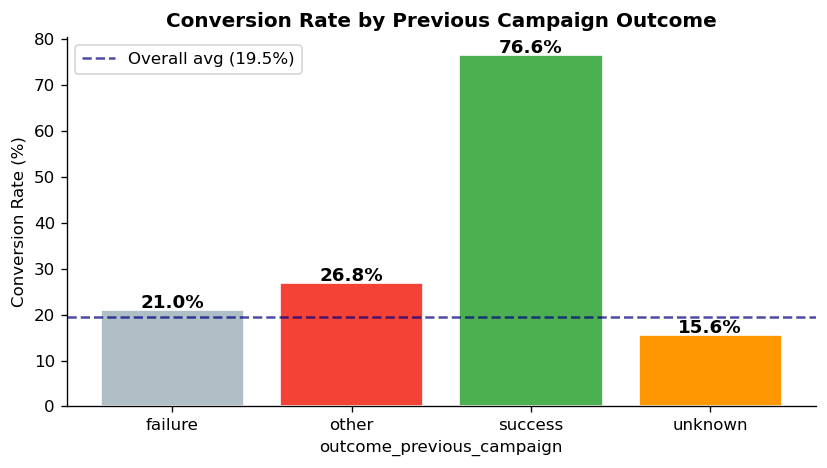


KEY INSIGHT — Previous Campaign Outcome Dominates Conversion Prediction:

  Customers with a prior SUCCESSFUL campaign outcome convert at dramatically
  higher rates than any other group. This is also confirmed by the Decision
  Tree feature importance plot, where 'outcome_previous_campaign_success'
  appears as one of the top features.

  PRACTICAL RECOMMENDATION FOR WALLACE COMMUNICATIONS:
  Prioritise re-contacting customers who responded positively in a prior
  campaign — this group has far higher expected value per call-centre call.
  Customers with a prior FAILURE outcome actually convert at below-average
  rates, suggesting limited value in calling them again without a new offer.
  The UNKNOWN group (never previously contacted) forms the largest segment
  and sits near the overall average — a viable broad-reach target.



In [26]:
# ── Insight: previous campaign outcome is the strongest conversion predictor ─
insight_df = df_raw.groupby('outcome_previous_campaign')['new_contract_this_campaign'].agg(
    total='count',
    conversions=lambda x: (x == 'yes').sum()
)
insight_df['conversion_rate_%'] = (insight_df['conversions'] / insight_df['total'] * 100).round(2)

print("Conversion rate by outcome_previous_campaign:")
print(insight_df.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
colors_ins = ['#B0BEC5', '#F44336', '#4CAF50', '#FF9800']
bars = ax.bar(insight_df.index, insight_df['conversion_rate_%'],
              color=colors_ins, edgecolor='white')
ax.set_title('Conversion Rate by Previous Campaign Outcome',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Conversion Rate (%)')
ax.set_xlabel('outcome_previous_campaign')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=11)
overall = df_raw['new_contract_this_campaign'].eq('yes').mean() * 100
ax.axhline(y=overall, linestyle='--', color='navy', alpha=0.7, label=f'Overall avg ({overall:.1f}%)')
ax.legend()
plt.tight_layout()
plt.savefig('insight_previous_campaign.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"""
KEY INSIGHT — Previous Campaign Outcome Dominates Conversion Prediction:

  Customers with a prior SUCCESSFUL campaign outcome convert at dramatically
  higher rates than any other group. This is also confirmed by the Decision
  Tree feature importance plot, where 'outcome_previous_campaign_success'
  appears as one of the top features.

  PRACTICAL RECOMMENDATION FOR WALLACE COMMUNICATIONS:
  Prioritise re-contacting customers who responded positively in a prior
  campaign — this group has far higher expected value per call-centre call.
  Customers with a prior FAILURE outcome actually convert at below-average
  rates, suggesting limited value in calling them again without a new offer.
  The UNKNOWN group (never previously contacted) forms the largest segment
  and sits near the overall average — a viable broad-reach target.
""")